In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

In [2]:
df=pd.read_csv("telecom data.csv")
print(df.info())
print(df.columns)
print(df.describe())
print(df.shape)
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 50 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Under 30                           7043 non-null   object 
 4   Senior Citizen                     7043 non-null   object 
 5   Married                            7043 non-null   object 
 6   Dependents                         7043 non-null   object 
 7   Number of Dependents               7043 non-null   int64  
 8   Country                            7043 non-null   object 
 9   State                              7043 non-null   object 
 10  City                               7043 non-null   object 
 11  Zip Code                           7043 non-null   int64

In [ ]:
# data cleaning
df.isnull().sum()
print(df.info())
print(df[["Churn Label" ,"Churn Category" ,"Churn Reason"]])
df["Churn Reason"]=df["Churn Reason"].fillna("No Churn")
print(df["Churn Reason"])
df["Churn Category"]=df["Churn Category"].fillna("Not applicable")
print(df["Churn Category"])
df["Churn Label"]=df["Churn Label"].str.strip()
print(df["Churn Label"])
print(df.isnull().sum())
df["Churn Label"]=df["Churn Label"].map({"Yes":1,"No":0})
print(df["Churn Label"])
df['Total Charges'].fillna(df['Total Charges'].median(), inplace=True)
print(df["Total Charges"])
df["Offer"]=df["Offer"].fillna("No Offer")
print(df["Offer"])
df["Internet Type"]=df["Internet Type"].fillna("No internet type")
print(df["Internet Type"])
df["Total Revenue"]=df["Total Revenue"].fillna(df["Total Revenue"].median())
print(df["Total Revenue"])
print(df)

Index(['Customer ID', 'Gender', 'Age', 'Under 30', 'Senior Citizen', 'Married',
       'Dependents', 'Number of Dependents', 'Country', 'State', 'City',
       'Zip Code', 'Latitude', 'Longitude', 'Population', 'Quarter',
       'Referred a Friend', 'Number of Referrals', 'Tenure in Months', 'Offer',
       'Phone Service', 'Avg Monthly Long Distance Charges', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Avg Monthly GB Download',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Revenue', 'Satisfaction Score', 'Customer Status', 'Churn Label',
       'Churn Score', 'CLTV', 'Churn Category', 'Churn Reason'],
      dtype='object')
Churn Label
0    73.46301

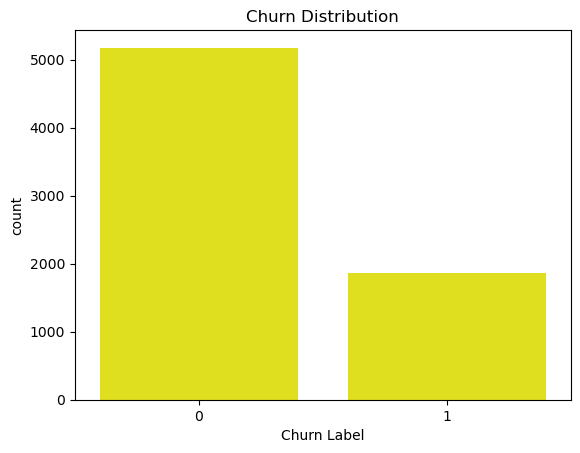

Gender
Female    0.269209
Male      0.261603
Name: Churn Label, dtype: float64


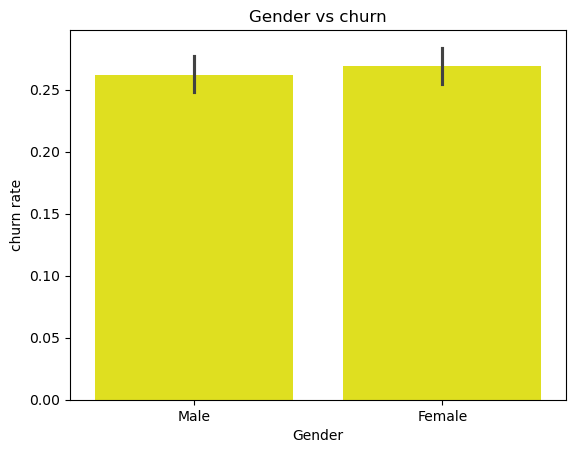

Age
Adult     3852
Senior    1662
Young     1529
Name: count, dtype: int64
Age
Young     0.223676
Adult     0.239097
Senior    0.364621
Name: Churn Label, dtype: float64


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_19564\3668249674.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_by_churn=df.groupby("Age")['Churn Label'].mean()


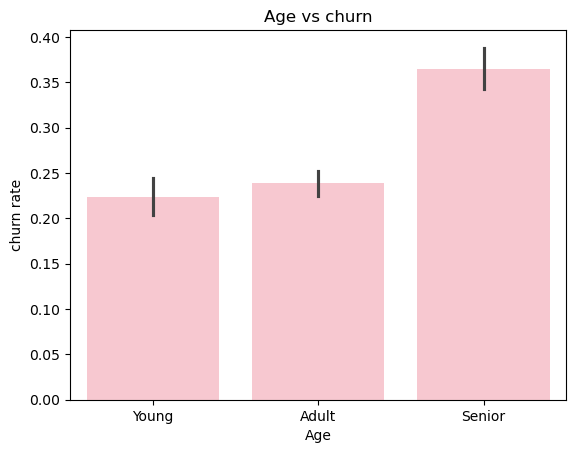

Under 30
No     0.277384
Yes    0.216988
Name: Churn Label, dtype: float64


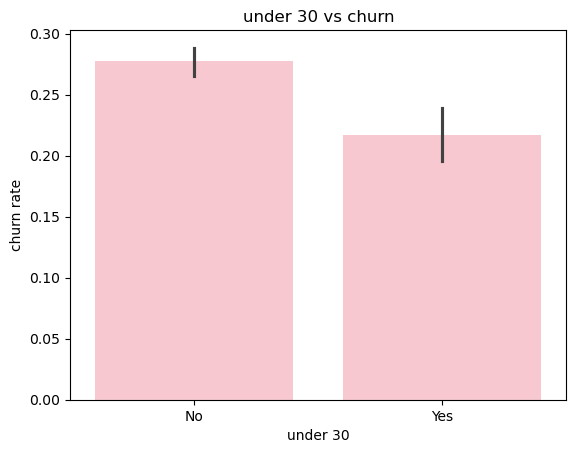

Senior Citizen
No     0.236062
Yes    0.416813
Name: Churn Label, dtype: float64


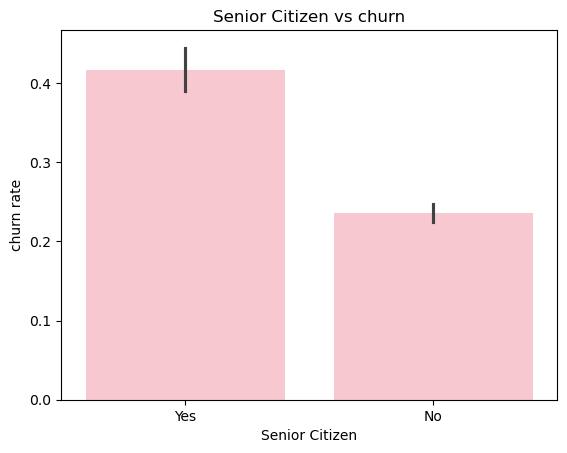

City
Los Angeles         293
San Diego           285
San Jose            112
Sacramento          108
San Francisco       104
                   ... 
South Lake Tahoe      2
Jacumba               2
Johannesburg          2
Holtville             2
Eldridge              2
Name: Churn Label, Length: 1106, dtype: int64


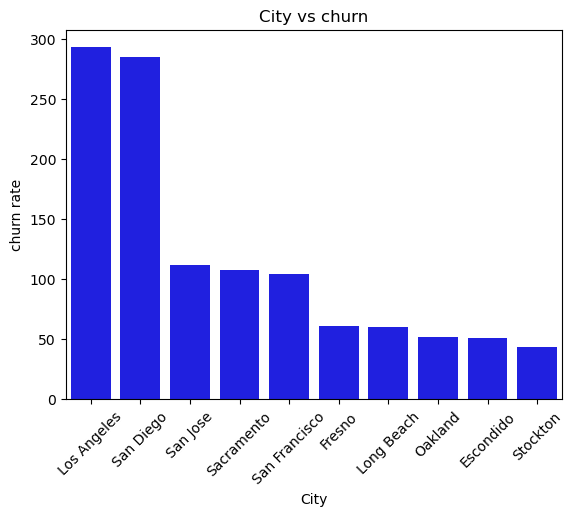

Referred a Friend
No     0.325831
Yes    0.193669
Name: Churn Label, dtype: float64


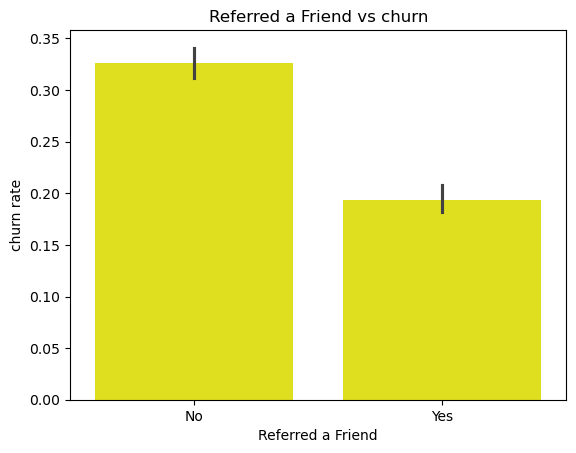

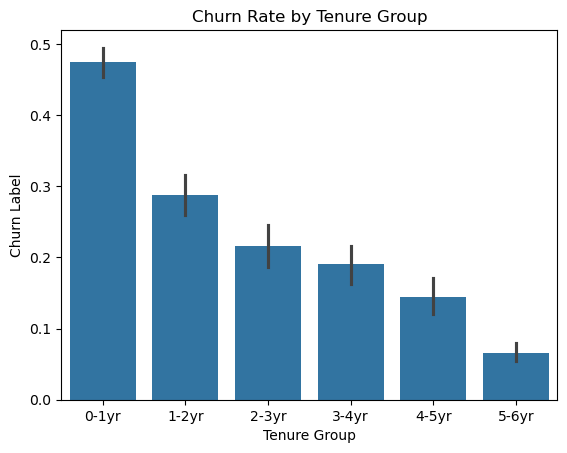

Number of Referrals
0     0.325831
1     0.466851
2     0.110169
3     0.125490
4     0.076271
5     0.079545
6     0.036199
7     0.024194
8     0.009390
9     0.016807
10    0.000000
11    0.000000
Name: Churn Label, dtype: float64


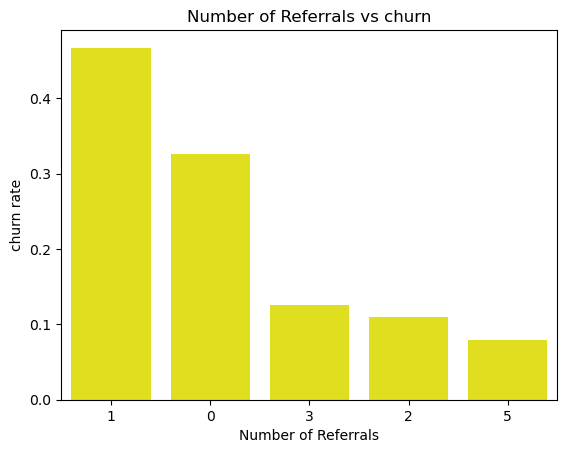

0
Offer
Offer E     0.529193
No Offer    0.271086
Offer D     0.267442
Offer C     0.228916
Offer B     0.122573
Offer A     0.067308
Name: Churn Label, dtype: float64


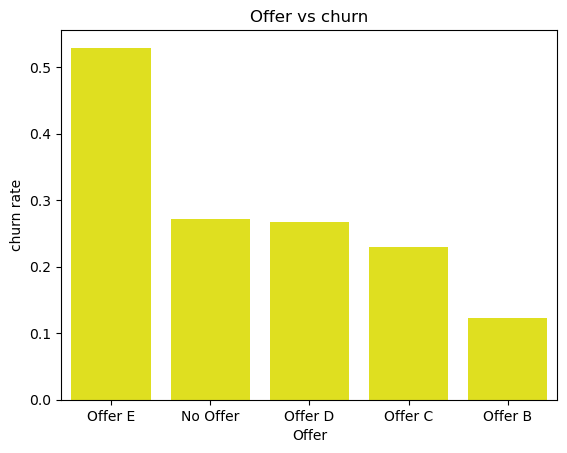

Phone Service
No     0.249267
Yes    0.267096
Name: Churn Label, dtype: float64


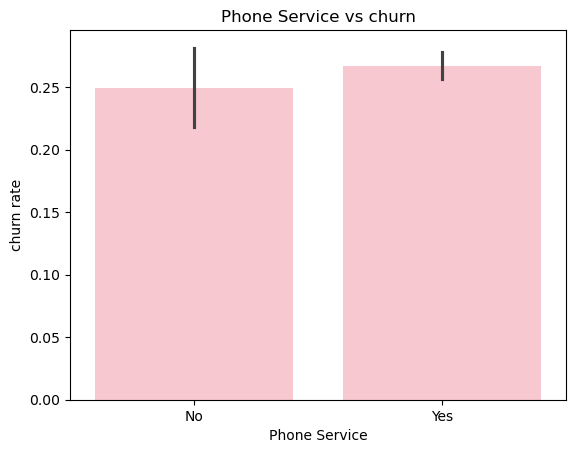

Internet Service
No     0.074050
Yes    0.318289
Name: Churn Label, dtype: float64


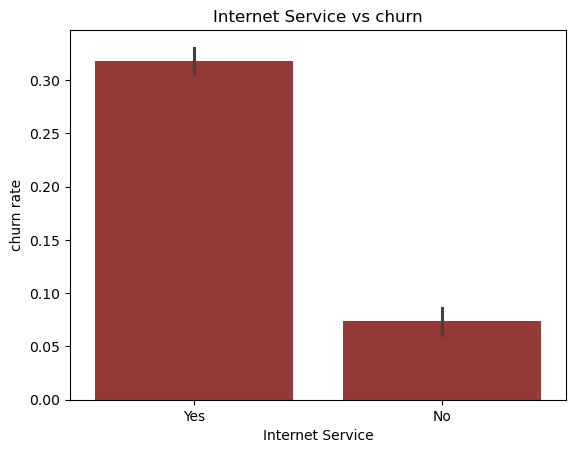

Internet Type
Fiber Optic         0.407249
Cable               0.256627
DSL                 0.185835
No internet type    0.074050
Name: Churn Label, dtype: float64


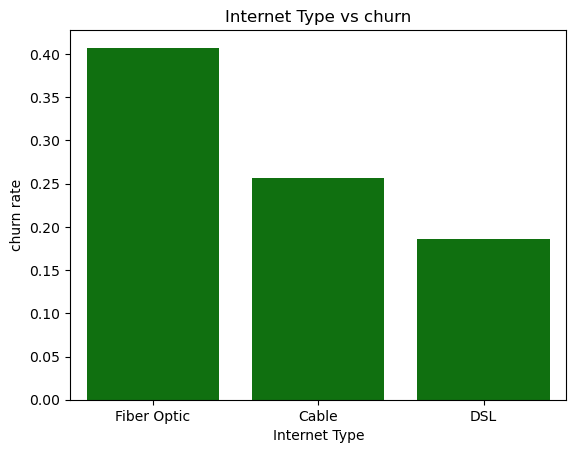

high usage
False    0.242991
True     0.297909
Name: Churn Label, dtype: float64


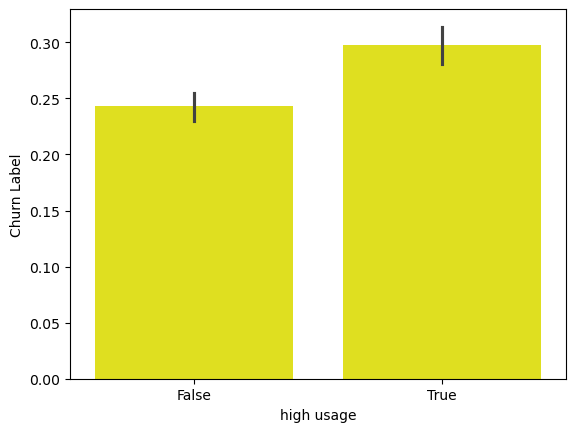

Online Security
No     0.313296
Yes    0.146112
Name: Churn Label, dtype: float64


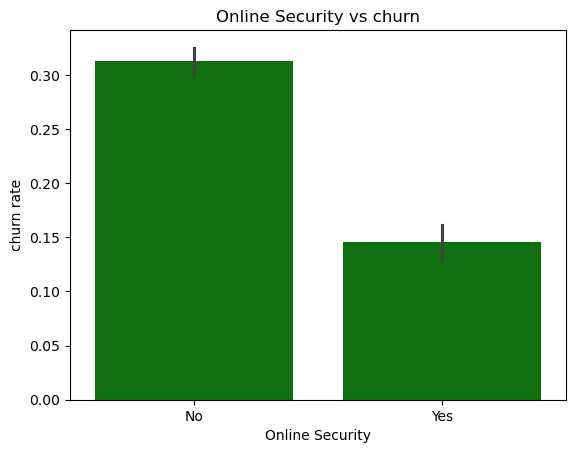

Online Backup
No     0.291721
Yes    0.215315
Name: Churn Label, dtype: float64


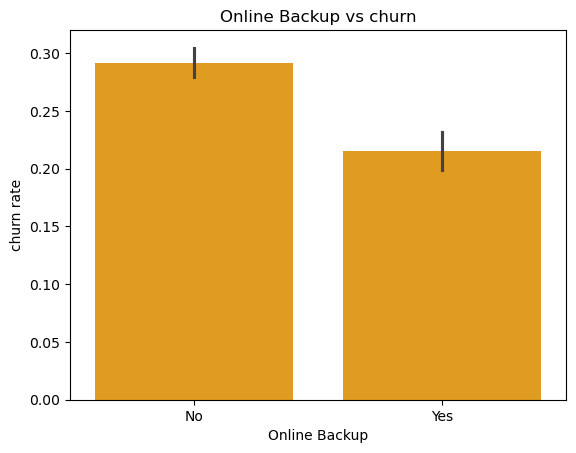

Premium Tech Support
No     0.311862
Yes    0.151663
Name: Churn Label, dtype: float64


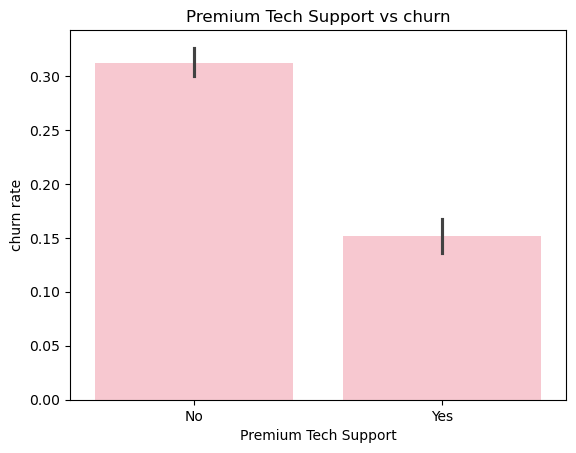

Streaming TV
No     0.243312
Yes    0.300702
Name: Churn Label, dtype: float64


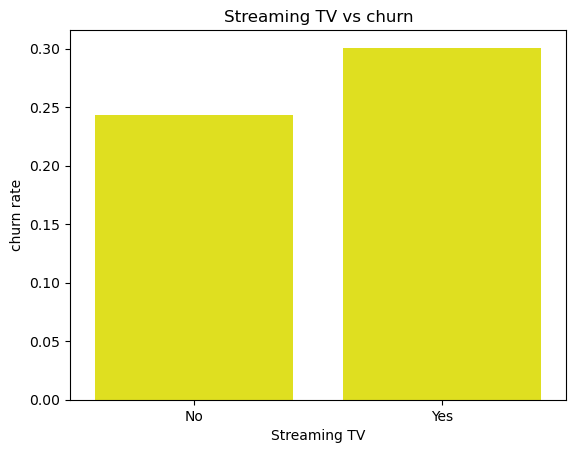

Streaming Movies
No     0.243795
Yes    0.299414
Name: Churn Label, dtype: float64


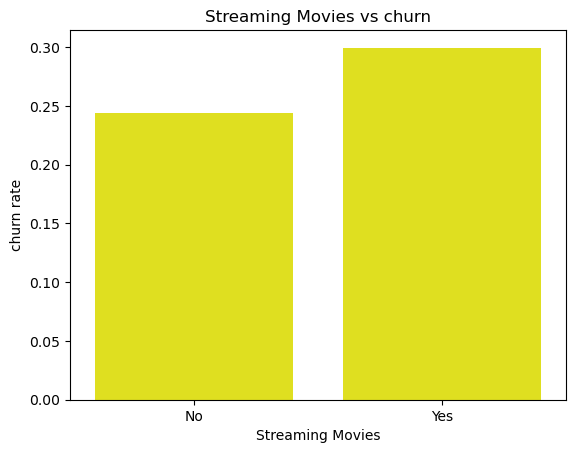

Streaming Music
No     0.250494
Yes    0.292605
Name: Churn Label, dtype: float64


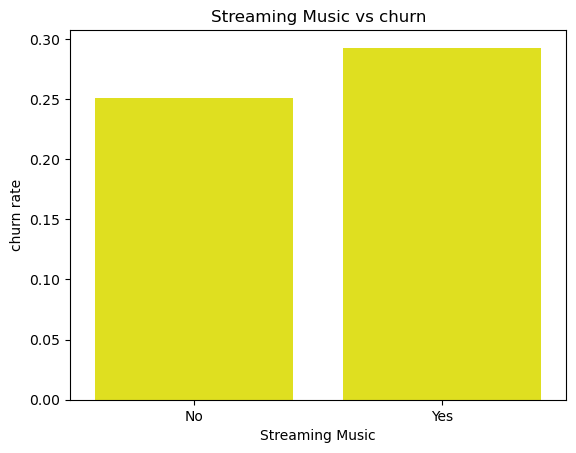

Unlimited Data
No     0.159704
Yes    0.316544
Name: Churn Label, dtype: float64


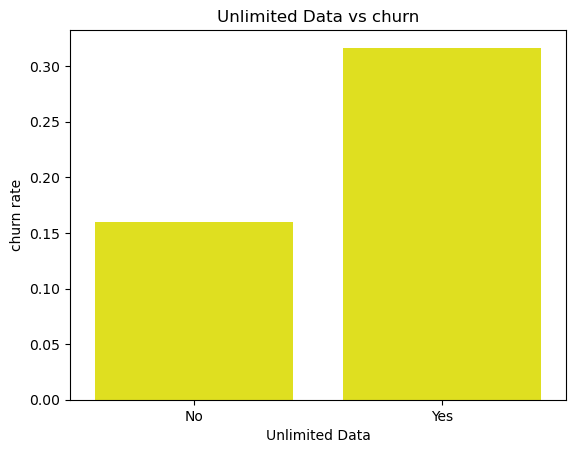

Contract
Month-to-Month    0.458449
One Year          0.107097
Two Year          0.025491
Name: Churn Label, dtype: float64


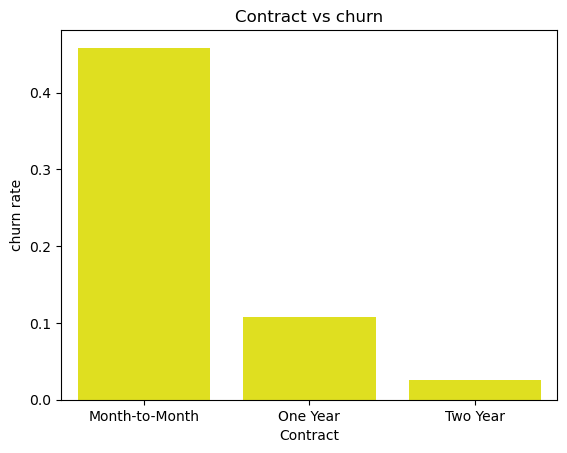

Paperless Billing
No     0.163301
Yes    0.335651
Name: Churn Label, dtype: float64


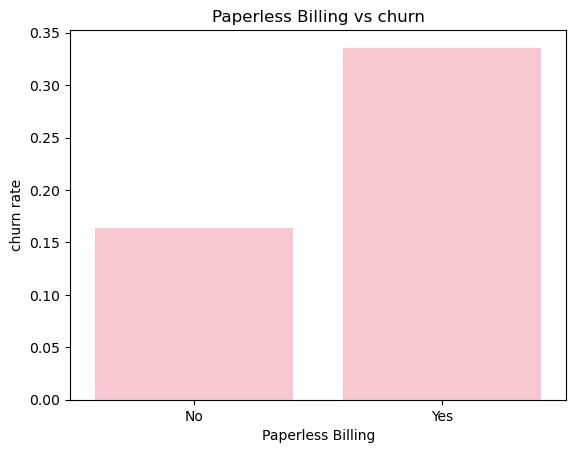

Payment Method
Mailed Check       0.368831
Bank Withdrawal    0.339985
Credit Card        0.144780
Name: Churn Label, dtype: float64


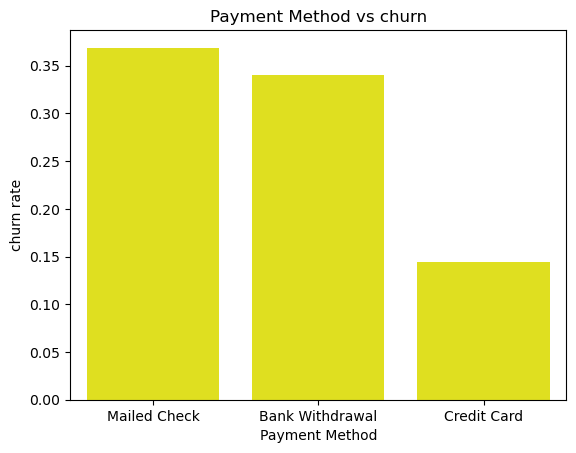

Churn Label
0    61.265124
1    74.441332
Name: Monthly Charge, dtype: float64


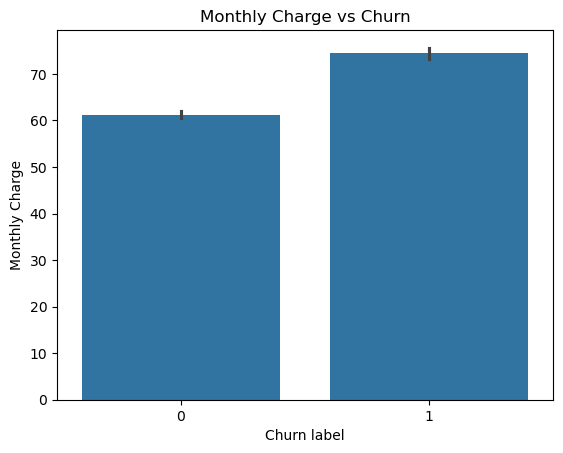

Extra Data User
False    0.258116
True     0.328297
Name: Churn Label, dtype: float64


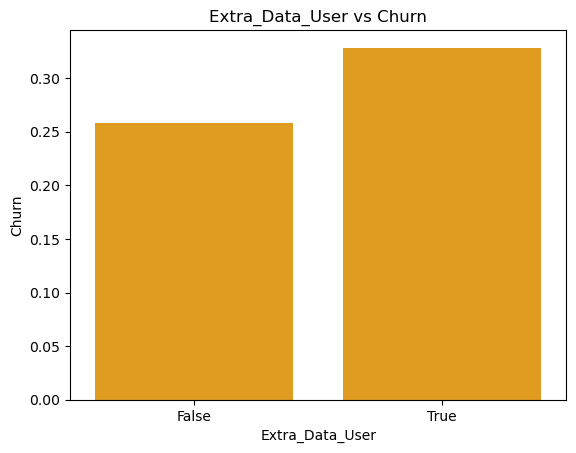

Churn Label
0    3418.374927
1    1971.353569
Name: Total Revenue, dtype: float64


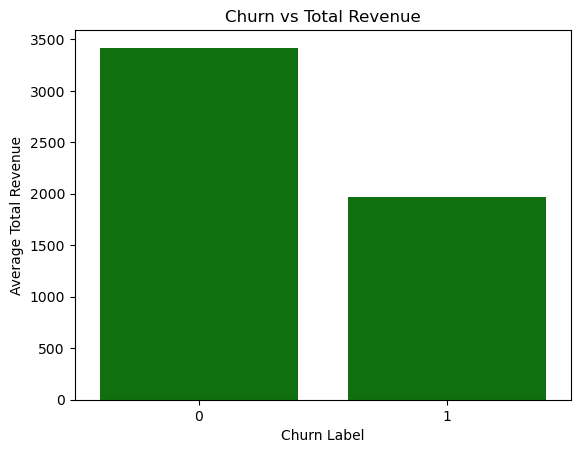

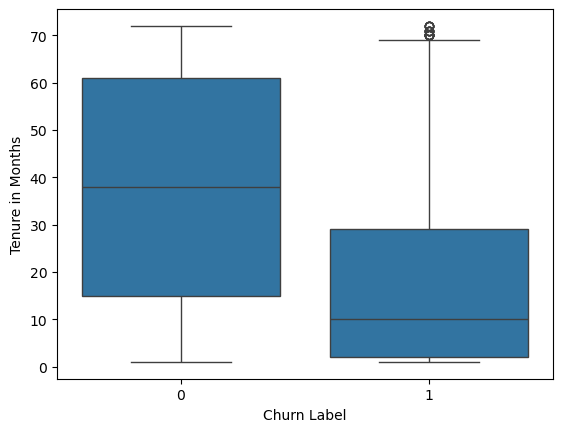

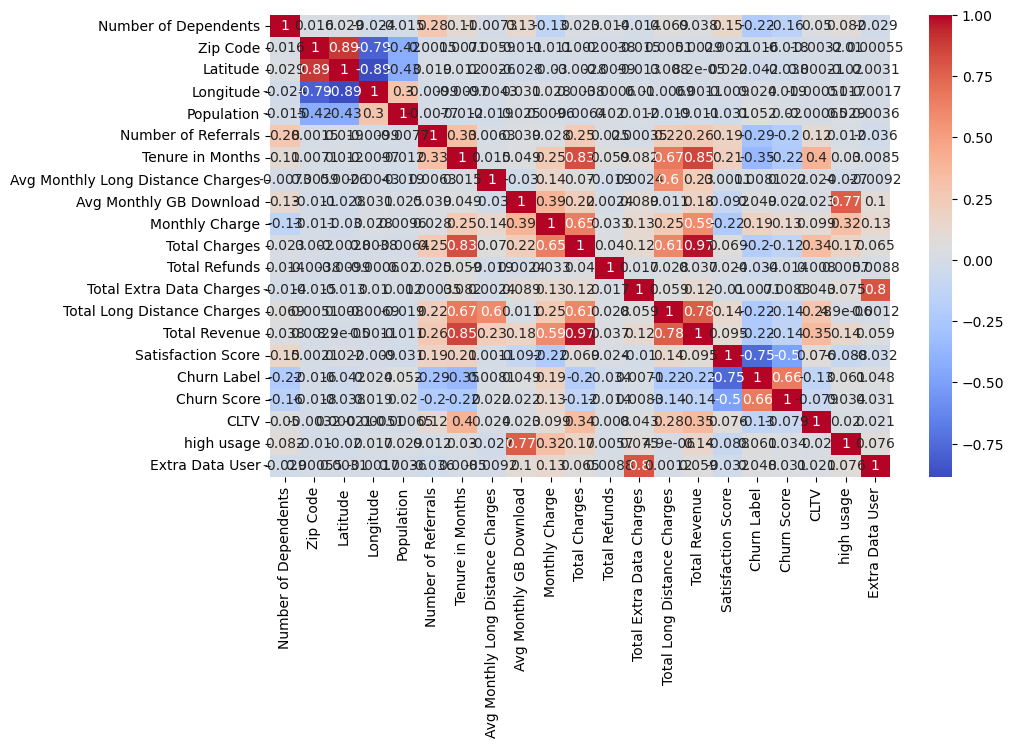

Index(['Customer ID', 'Gender', 'Age', 'Under 30', 'Senior Citizen', 'Married',
       'Dependents', 'Number of Dependents', 'Country', 'State', 'City',
       'Population', 'Referred a Friend', 'Number of Referrals',
       'Tenure in Months', 'Offer', 'Phone Service', 'Internet Service',
       'Internet Type', 'Avg Monthly GB Download', 'Online Security',
       'Online Backup', 'Device Protection Plan', 'Premium Tech Support',
       'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data',
       'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charge',
       'Churn Label', 'high usage', 'Extra Data User'],
      dtype='object')


In [4]:
# # Exploratory data analysis
print(df.columns)
count_churnrate=df["Churn Label"].value_counts(normalize=True)*100
print(count_churnrate)
sns.countplot(x="Churn Label",data=df,color="yellow")
plt.title("Churn Distribution")
plt.show()

gender_by_churn=df.groupby("Gender")["Churn Label"].mean()
print(gender_by_churn)
sns.barplot(x="Gender",y="Churn Label",data=df,color="yellow")
plt.xlabel("Gender")
plt.ylabel("churn rate")
plt.title("Gender vs churn")
plt.show()

df['Age'] = pd.cut(
    df['Age'],
    bins=[0, 30, 60, 100],
    labels=['Young', 'Adult', 'Senior']
)
print(df["Age"].value_counts())
age_by_churn=df.groupby("Age")['Churn Label'].mean()
print(age_by_churn)
sns.barplot(x="Age",y="Churn Label",data=df,color="pink")
plt.xlabel("Age")
plt.ylabel("churn rate")
plt.title("Age vs churn")
plt.show()

under30_by_churn=df.groupby("Under 30")["Churn Label"].mean()
print(under30_by_churn)
sns.barplot(x="Under 30",y="Churn Label",data=df,color="pink")
plt.xlabel("under 30")
plt.ylabel("churn rate")
plt.title("under 30 vs churn")
plt.show()

seniorCitizen_totalRevenue=df.groupby('Senior Citizen')["Churn Label"].mean()
print(seniorCitizen_totalRevenue)
sns.barplot(x="Senior Citizen",y="Churn Label",data=df,color="pink")
plt.xlabel("Senior Citizen")
plt.ylabel("churn rate")
plt.title("Senior Citizen vs churn")
plt.show()

city_by_churn=df.groupby("City")["Churn Label"].count().sort_values(ascending=False)
top10_cities=city_by_churn.head(10)
print(city_by_churn)
sns.barplot(x=top10_cities.index,y=top10_cities.values,color="blue")
plt.xlabel("City")
plt.ylabel("churn rate")
plt.title("City vs churn")
plt.xticks(rotation=45)
plt.show()

Referred_by_churn=df.groupby("Referred a Friend")["Churn Label"].mean()
print(Referred_by_churn)
df.groupby("Referred a Friend").agg({
    "Churn Label": ["mean", "count"]
})
sns.barplot(x="Referred a Friend",y="Churn Label",data=df,color="yellow")
plt.xlabel("Referred a Friend")
plt.ylabel("churn rate")
plt.title("Referred a Friend vs churn")
plt.show()


df["Tenure Group"] = pd.cut(df["Tenure in Months"],
                           bins=[0, 12, 24, 36, 48, 60, 72],
                           labels=["0-1yr","1-2yr","2-3yr","3-4yr","4-5yr","5-6yr"])

sns.barplot(x="Tenure Group", y="Churn Label", data=df)
plt.title("Churn Rate by Tenure Group")
plt.show()

NoofReferrals_by_churn=df.groupby("Number of Referrals")["Churn Label"].mean()
print(NoofReferrals_by_churn)
top5_referrals=NoofReferrals_by_churn.sort_values(ascending=False).head(5)
sns.barplot(x=top5_referrals.index,y=top5_referrals.values,color="yellow", order=top5_referrals.index)
plt.xlabel("Number of Referrals")
plt.ylabel("churn rate")
plt.title("Number of Referrals vs churn")
plt.show()

print(df["Offer"].isnull().sum())
offer_by_churn=df.groupby("Offer")["Churn Label"].mean().sort_values(ascending=False)
top5_offers=offer_by_churn.head(5)
print(offer_by_churn)
sns.barplot(x=top5_offers.index,y=top5_offers.values,color="yellow")
plt.xlabel("Offer")
plt.ylabel("churn rate")
plt.title("Offer vs churn")
plt.show()

phoneServices_by_churn=df.groupby('Phone Service')["Churn Label"].mean()
print(phoneServices_by_churn)
sns.barplot(x="Phone Service",y="Churn Label",data=df,color="pink")
plt.xlabel("Phone Service")
plt.ylabel("churn rate")
plt.title("Phone Service vs churn")
plt.show()

internet_Services=df.groupby("Internet Service")["Churn Label"].mean()
print(internet_Services)
sns.barplot(x="Internet Service",y="Churn Label",data=df,color="brown")
plt.xlabel("Internet Service")
plt.ylabel("churn rate")
plt.title("Internet Service vs churn")
plt.show()

internt_type=df.groupby('Internet Type')["Churn Label"].mean().sort_values(ascending=False)
print(internt_type)
top5_internet=internt_type.head(3)
sns.barplot(x=top5_internet.index,y=top5_internet.values,color="green")
plt.xlabel("Internet Type")
plt.ylabel("churn rate")
plt.title("Internet Type vs churn")
plt.show()

df["high usage"]=df["Avg Monthly GB Download"]>20
high_usage=df.groupby("high usage")["Churn Label"].mean()
print(high_usage)
sns.barplot(x="high usage",y="Churn Label",data=df,color="yellow")
plt.show()

security=df.groupby("Online Security")["Churn Label"].mean()
print(security)
sns.barplot(x="Online Security",y="Churn Label",data=df,color="green")
plt.xlabel("Online Security")
plt.ylabel("churn rate")
plt.title("Online Security vs churn")
plt.show()
#  👉 Without Online Security (No)
#  → churn rate = 0.313 (31.3%) ❌ HIGH Churn rate
#  👉 With Online Security (Yes)
#  → churn rate = 0.146 (14.6%) ✅ LOW Churn rate

backup=df.groupby('Online Backup')['Churn Label'].mean()
print(backup)
sns.barplot(x="Online Backup",y="Churn Label",data=df,color="orange")
plt.xlabel("Online Backup")
plt.ylabel("churn rate")
plt.title("Online Backup vs churn")
plt.show()

tech_support=df.groupby("Premium Tech Support")["Churn Label"].mean()
print(tech_support)
sns.barplot(x="Premium Tech Support",y="Churn Label",data=df,color="pink")
plt.xlabel("Premium Tech Support")
plt.ylabel("churn rate")
plt.title("Premium Tech Support vs churn")
plt.show()
 # Customers with:
 # No Tech Support → ~31.2% churn ❌
# With Tech Support → ~15.2% churn ✅
#  Customers who have tech support are much less likely to leave

tv_streaming=df.groupby('Streaming TV')["Churn Label"].mean()   
print(tv_streaming)
sns.barplot(x=tv_streaming.index, y=tv_streaming.values,color="yellow")
plt.xlabel("Streaming TV")
plt.ylabel("churn rate")
plt.title("Streaming TV vs churn")
plt.show()
#  “Customers who use Streaming TV have a higher churn rate compared to non-users.”

Streaming_Movies=df.groupby("Streaming Movies")["Churn Label"].mean()
print(Streaming_Movies)
sns.barplot(x=Streaming_Movies.index, y=Streaming_Movies.values,color="yellow")
plt.xlabel("Streaming Movies")
plt.ylabel("churn rate")
plt.title("Streaming Movies vs churn")
plt.show()

Streaming_Music=df.groupby("Streaming Music")["Churn Label"].mean()
print(Streaming_Music)
sns.barplot(x=Streaming_Music.index, y=Streaming_Music.values,color="yellow")
plt.xlabel("Streaming Music")
plt.ylabel("churn rate")
plt.title("Streaming Music vs churn")
plt.show()

Unlimited_Data=df.groupby("Unlimited Data")["Churn Label"].mean()
print(Unlimited_Data)
sns.barplot(x=Unlimited_Data.index, y=Unlimited_Data.values,color="yellow")
plt.xlabel("Unlimited Data")
plt.ylabel("churn rate")
plt.title("Unlimited Data vs churn")
plt.show()
# # “Customers on unlimited data plans have significantly higher churn compared to non-unlimited users.”

contract=df.groupby("Contract")["Churn Label"].mean()
print(contract)
sns.barplot(x=contract.index,y=contract.values,color="yellow")
plt.xlabel("Contract")
plt.ylabel("churn rate")
plt.title("Contract vs churn")
plt.show()

Paperless_Billing=df.groupby("Paperless Billing")["Churn Label"].mean()
print(Paperless_Billing)
sns.barplot(x=Paperless_Billing.index,y=Paperless_Billing.values,color="pink")
plt.xlabel("Paperless Billing")
plt.ylabel("churn rate")
plt.title("Paperless Billing vs churn")
plt.show()
# # # Customers using paperless billing churn much more

Payment_Method=df.groupby("Payment Method")["Churn Label"].mean().sort_values(ascending=False)
print(Payment_Method)
sns.barplot(x=Payment_Method.index, y=Payment_Method.values,color="yellow")
plt.xlabel("Payment Method")
plt.ylabel("churn rate")
plt.title("Payment Method vs churn")
plt.show()

Monthly_Charge=df.groupby("Churn Label")['Monthly Charge'].mean()
print(Monthly_Charge)
sns.barplot(x=df["Churn Label"], y=df["Monthly Charge"])
plt.xlabel("Churn label")
plt.ylabel("Monthly Charge")
plt.title("Monthly Charge vs Churn")
plt.show()
# # Higher monthly charges are strongly linked to higher churn


df["Extra Data User"] = df["Total Extra Data Charges"] > 0
Extra_Data_User=df.groupby("Extra Data User")["Churn Label"].mean()
print(Extra_Data_User)
sns.barplot(x=Extra_Data_User.index, y=Extra_Data_User.values,color='orange')
plt.xlabel("Extra_Data_User")
plt.ylabel("Churn")
plt.title("Extra_Data_User vs Churn")
plt.show()
#  # Customers who incur extra data charges are more likely to churn


total_revenue=df.groupby("Churn Label")["Total Revenue"].mean()
print(total_revenue)
sns.barplot(
    x=total_revenue.index,
    y=total_revenue.values,
    color="green"
)
plt.xlabel("Churn Label")
plt.ylabel("Average Total Revenue")
plt.title("Churn vs Total Revenue")
plt.show()

sns.boxplot(x="Churn Label", y="Tenure in Months", data=df)
plt.show()
# Correlation Analysis
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()


df.drop("Total Charges", axis=1, inplace=True)
df = df.drop("Total Refunds", axis=1)
df = df.drop('Total Long Distance Charges', axis=1)
df.drop("Customer Status", axis=1, inplace=True)
df.drop("Churn Score", axis=1, inplace=True)
df.drop("CLTV", axis=1, inplace=True)
df.drop("Churn Category",axis=1,inplace=True)
df.drop("Multiple Lines",axis=1,inplace=True)
df.drop("Churn Reason",axis=1,inplace=True)
df.drop("Zip Code",axis=1,inplace=True)
df.drop("Latitude",axis=1,inplace=True)
df.drop("Longitude",axis=1,inplace=True)
df.drop("Quarter",axis=1,inplace=True)
df = df.drop("Satisfaction Score", axis=1)
df.drop("Tenure Group", axis=1, inplace=True)
df.drop("Total Revenue",axis=1,inplace=True)
df.drop('Total Extra Data Charges',axis=1,inplace=True)
df.drop("Avg Monthly Long Distance Charges",axis=1,inplace=True)
print(df.columns)    

In [ ]:

from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score,roc_curve,roc_auc_score,f1_score,precision_recall_curve
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
import joblib
import pandas as pd
print("********modeling**********")
# X=df.drop("Churn Label",axis=1)
# Y=df["Churn Label"]
# num_cols = X.select_dtypes(include=["int64", "float64"]).columns
# cat_cols = X.select_dtypes(include=["object","string", "category", "bool"]).columns
# num_pipeline=StandardScaler()
# cat_pipeline=OneHotEncoder(drop="first",handle_unknown="ignore")
# X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)
# preprocessor=ColumnTransformer([
#     ("num",num_pipeline,num_cols),
#     ("cat",cat_pipeline,cat_cols)
# ])
# pipeline=Pipeline([
#     ("processor",preprocessor),
#     ("smote",SMOTE(random_state=42)),
#     ("model",RandomForestClassifier(n_estimators=100,max_depth = None, min_samples_split=5,
#     min_samples_leaf=2,))
# ])
# pipeline.fit(X_train,Y_train)
# y_pred=pipeline.predict(X_test)
# print(y_pred)
# print("classification report:",classification_report(Y_test,y_pred))
# print("confusion matrix:",confusion_matrix(Y_test,y_pred))
# print("accuracy:",accuracy_score(Y_test,y_pred))
# print("f1_score:",f1_score(Y_test,y_pred))
# y_prob=pipeline.predict_proba(X_test)[:,1]
# threshold=0.5
# custom=(y_prob>threshold).astype(int)
# fpr,tpr,threshold=roc_curve(Y_test,y_prob)
# print("roc_curve score:",roc_auc_score(Y_test,y_prob))
# plt.Figure(figsize=(6,6))
# plt.plot(fpr,tpr)
# plt.title("ROC Curve")
# plt.show()
# precision, recall, thresholds = precision_recall_curve(Y_test, y_prob)
# plt.plot(recall, precision)
# plt.xlabel("Recall")
# plt.ylabel("Precision")
# plt.title("Precision-Recall Curve")
# plt.show()
# joblib.dump(pipeline,"model.pkl")
# print("Model saved successfully!")
# # loaded_model=joblib.load("model.pkl")
# # loaded_model.predict(X_test)




print("******** MODELING **********")

# Select only the features you want
selected_features = [
    "Gender",
    "Age",
    "Senior Citizen",
    "Married",
    "Dependents",
    "Tenure in Months",
    "Offer",
    "Phone Service",
    "Internet Service",
    "Internet Type",
    "Online Security",
    "Online Backup",
    "Device Protection Plan",
    "Premium Tech Support",
    "Streaming TV",
    "Streaming Movies",
    "Contract",
    "Paperless Billing",
    "Payment Method",
    "Monthly Charge"
]

X = df[selected_features]
Y = df["Churn Label"]

# Numerical and categorical columns
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns

# Preprocessing
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)
])

# Train/Test Split
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

# Pipeline
pipeline = Pipeline([
    ("processor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(
        n_estimators=100,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42
    ))
])

# Train model
pipeline.fit(X_train, Y_train)

# Save model
joblib.dump(pipeline, "model.pkl")
print("Model saved successfully!")
